In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# 1. CARICAMENTO DATI
# ============================================================
df = pd.read_csv("/kaggle/input/datasets/oladimejiwilliams/energydata-complete/energydata_complete.csv",
header= 0,encoding= 'unicode_escape')
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Dimensioni dataset:", df.shape)



Dimensioni dataset: (19735, 29)


In [2]:
# ============================================================
# 2. FEATURE TEMPORALI (calendario + cicliche)
# ============================================================
df["hour"] = df["date"].dt.hour
df["minute"] = df["date"].dt.minute
df["dayofweek"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month

time_in_hours = df["hour"] + df["minute"] / 60
df["hour_sin"] = np.sin(2 * np.pi * time_in_hours / 24)
df["hour_cos"] = np.cos(2 * np.pi * time_in_hours / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

In [3]:
# ============================================================
# 3. FEATURE DI LAG (valori passati di Appliances)
# Dati ogni 10 minuti: 1=10min, 6=1h, 12=2h, 144=1 giorno, 1008=7 giorni
# ============================================================
lags = [1, 2, 3, 6, 12, 144, 1008]
for lag in lags:
    df[f"Appliances_lag_{lag}"] = df["Appliances"].shift(lag)


In [4]:
# ============================================================
# 4. STATISTICHE MOBILI (calcolate UNA SOLA VOLTA, causali)
# shift(1) prima di rolling -> non si usa mai il valore corrente
# ============================================================
df["Appliances_roll_mean_1h"] = df["Appliances"].shift(1).rolling(6).mean()
df["Appliances_roll_std_1h"] = df["Appliances"].shift(1).rolling(6).std()
df["Appliances_roll_mean_3h"] = df["Appliances"].shift(1).rolling(18).mean()
df["Appliances_roll_mean_24h"] = df["Appliances"].shift(1).rolling(144).mean()
df["Appliances_roll_mean_7d"] = df["Appliances"].shift(1).rolling(1008).mean()


In [5]:
# ============================================================
# 5. FEATURE METEO SEMPLICI DEL MOMENTO (già presenti nel csv)
# ============================================================
weather_cols = ["T_out", "RH_out", "Windspeed", "lights"]

feature_cols = (
    ["Appliances", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month"]
    + [f"Appliances_lag_{lag}" for lag in lags]
    + ["Appliances_roll_mean_1h", "Appliances_roll_std_1h",
       "Appliances_roll_mean_3h", "Appliances_roll_mean_24h",
       "Appliances_roll_mean_7d"]
    + weather_cols
)




In [6]:
# ============================================================
# 6. ORIZZONTI DI PREVISIONE (in passi da 10 minuti)
# ============================================================
HORIZONS = {
    "1 ora": 6,
    "2 ore": 12,
    "6 ore": 36,
    "12 ore": 72,
    "24 ore": 144,
    "1 settimana": 1008,
}


def build_dataset(df, horizon_steps):
    """Crea il target shiftato in avanti di `horizon_steps` e ripulisce i NaN."""
    d = df.copy()
    d["target"] = d["Appliances"].shift(-horizon_steps)
    d = d.dropna(subset=feature_cols + ["target"]).reset_index(drop=True)
    return d


def train_val_test_split(d):
    n = len(d)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)
    X = d[feature_cols]
    Y = d["target"]
    return (
        X.iloc[:train_end], Y.iloc[:train_end],
        X.iloc[train_end:val_end], Y.iloc[train_end:val_end],
        X.iloc[val_end:], Y.iloc[val_end:],
    )

In [7]:
# ============================================================
# 7. TRAINING + VALUTAZIONE PER OGNI ORIZZONTE (solo XGBoost)
# ============================================================
results = []
test_results = {}   # horizon_name -> (Y_test, pred)  -> serve per i grafici

for horizon_name, horizon_steps in HORIZONS.items():
    print(f"\n=== Orizzonte: {horizon_name} ({horizon_steps} passi) ===")

    d = build_dataset(df, horizon_steps)
    X_train, Y_train, X_val, Y_val, X_test, Y_test = train_val_test_split(d)

    model = XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(
        X_train, Y_train,
        eval_set=[(X_val, Y_val)],
        verbose=False,
    )

    pred = model.predict(X_test)

    mae = mean_absolute_error(Y_test, pred)
    rmse = np.sqrt(mean_squared_error(Y_test, pred))
    r2 = r2_score(Y_test, pred)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    results.append({"orizzonte": horizon_name, "MAE": mae, "RMSE": rmse, "R2": r2})
    test_results[horizon_name] = (Y_test.reset_index(drop=True), pred)




=== Orizzonte: 1 ora (6 passi) ===
MAE  : 52.0482
RMSE : 88.6489
R²   : 0.0601

=== Orizzonte: 2 ore (12 passi) ===
MAE  : 65.6253
RMSE : 98.7240
R²   : -0.1654

=== Orizzonte: 6 ore (36 passi) ===
MAE  : 70.7100
RMSE : 104.1256
R²   : -0.2950

=== Orizzonte: 12 ore (72 passi) ===
MAE  : 84.8796
RMSE : 124.7167
R²   : -0.8554

=== Orizzonte: 24 ore (144 passi) ===
MAE  : 73.7315
RMSE : 110.4081
R²   : -0.4637

=== Orizzonte: 1 settimana (1008 passi) ===
MAE  : 52.4531
RMSE : 92.2804
R²   : 0.0114


In [8]:
# ============================================================
# 8. TABELLA RIASSUNTIVA
# ============================================================
results_df = pd.DataFrame(results)
print("\n================ RIEPILOGO ================")
print(results_df.to_string(index=False))




================ RIEPILOGO ================
  orizzonte       MAE       RMSE        R2
      1 ora 52.048215  88.648870  0.060095
      2 ore 65.625290  98.724033 -0.165385
      6 ore 70.710009 104.125613 -0.294995
     12 ore 84.879603 124.716742 -0.855413
     24 ore 73.731543 110.408074 -0.463659
1 settimana 52.453138  92.280389  0.011420


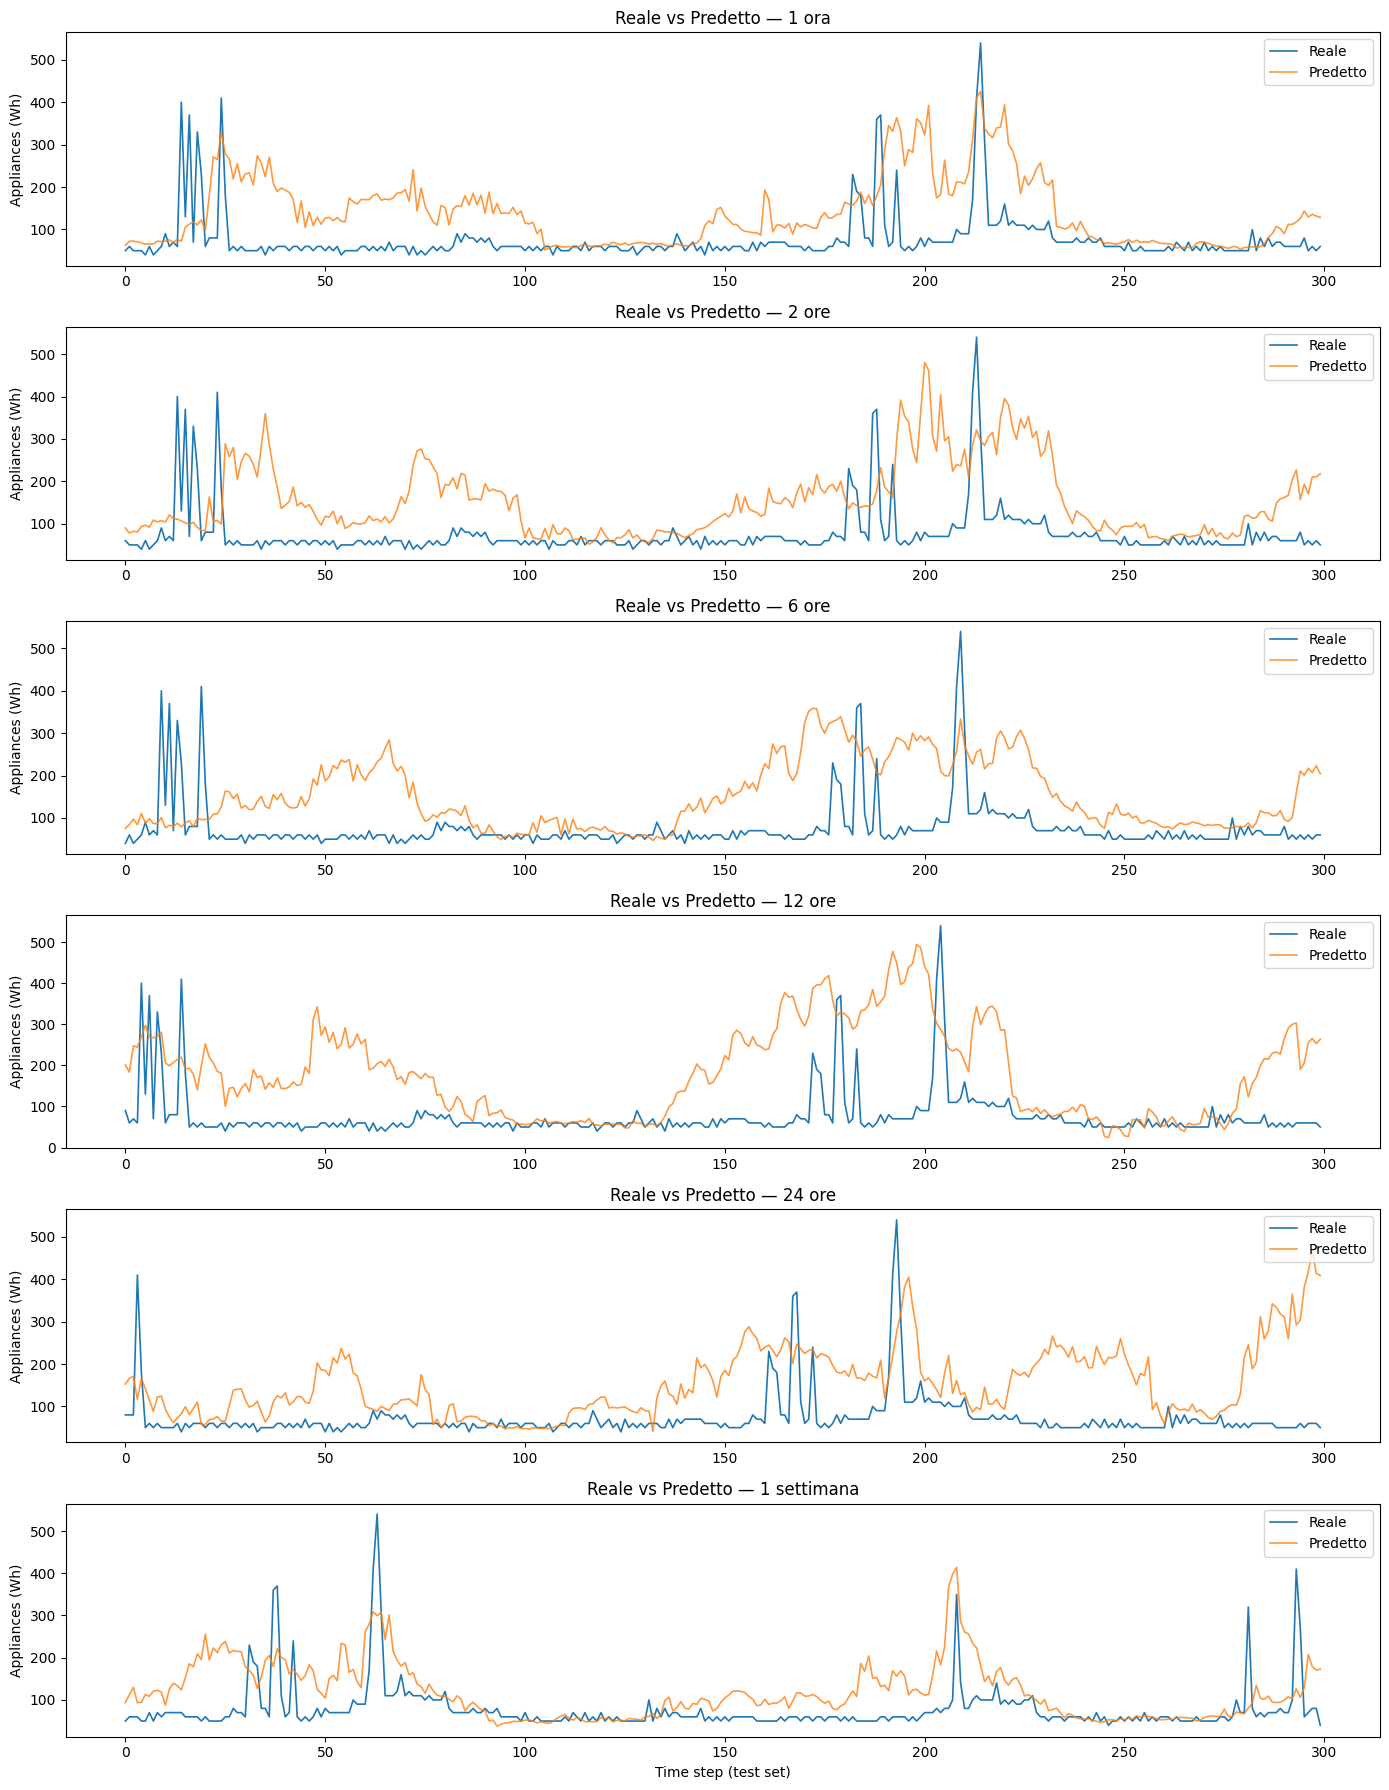

In [9]:

# ============================================================
# 9. GRAFICI: reale vs predetto per ogni orizzonte
#
# ============================================================
N_POINTS = 300  # quanti punti del test set mostrare per leggibilità

n_horizons = len(HORIZONS)
fig, axes = plt.subplots(n_horizons, 1, figsize=(14, 3 * n_horizons), sharex=False)

for ax, (horizon_name, (Y_test, pred)) in zip(axes, test_results.items()):
    y_plot = Y_test.values[:N_POINTS]
    p_plot = pred[:N_POINTS]

    ax.plot(y_plot, label="Reale", linewidth=1.2)
    ax.plot(p_plot, label="Predetto", linewidth=1.2, alpha=0.8)
    ax.set_title(f"Reale vs Predetto — {horizon_name}")
    ax.set_ylabel("Appliances (Wh)")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Time step (test set)")
plt.tight_layout()
plt.show()

# Conclusione
Non è adatto
